<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/Assignment4_Fong_Marcela/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NER Notebook 1: Inference & Rule-Based NER
## Social Media Domain — Broad Twitter Corpus

**BSAN 6200 — Text Mining & Social Media Analytics**

###  Dataset Selection and Domain Justification
- **Name:** Broad Twitter Corpus (GateNLP)
- **Source:** https://huggingface.co/datasets/GateNLP/broad_twitter_corpus
- **Entity Types:** PERSON, LOCATION, ORGANIZATION
- **Domain:** Tweets — short, informal, noisy social media text
- **Why this domain?** Twitter/X text has unique NER challenges: abbreviations, hashtags,
  @mentions, slang, lack of capitalization, and rapidly changing named entities.


---

---
## Part 1: Load the Broad Twitter Corpus

The Broad Twitter Corpus contains ~9,000 annotated tweets.
We will load it from HuggingFace and inspect a sample.

**Key challenges in social media NER:**
- Inconsistent capitalization (`elon musk` vs `Elon Musk`)
- Hashtags and mentions (`#Apple`, `@realDonaldTrump`)
- Abbreviations and slang (`tbh`, `smh`, `lol`)
- Missing punctuation and grammar
- URLs embedded in text


In [1]:
!pip install -q "datasets<4.0.0" spacy transformers seqeval torch
!python -m spacy download en_core_web_sm

from datasets import load_dataset
import spacy
from spacy import displacy
import nltk
from transformers import pipeline
import json
import re
from collections import Counter
import requests

# NLTK downloads
nltk.download("punkt", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("maxent_ne_chunker", quiet=True)
nltk.download("words", quiet=True)

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

print(f"spaCy model loaded: {nlp.meta['name']}")
print(f"Pipeline components: {nlp.pipe_names}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy model loaded: core_web_sm
Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [2]:
from datasets import load_dataset

dataset = load_dataset("GateNLP/broad_twitter_corpus")
print(dataset)
print(dataset["train"][0])
print(dataset["train"][3000])
print(dataset["train"][50])
print(dataset["train"][401])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

broad_twitter_corpus.py: 0.00B [00:00, ?B/s]

broad-twitter-corpus/train/0000.parquet:   0%|          | 0.00/449k [00:00<?, ?B/s]

broad-twitter-corpus/validation/0000.par(…):   0%|          | 0.00/163k [00:00<?, ?B/s]

broad-twitter-corpus/test/0000.parquet:   0%|          | 0.00/192k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5342 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2002 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2002 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 5342
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 2002
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 2002
    })
})
{'id': '0', 'tokens': ['I', 'hate', 'the', 'words', 'chunder', ',', 'vomit', 'and', 'puke', '.', 'BUUH', '.'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}
{'id': '3000', 'tokens': ['Right', ',', 'THAT', "'S", 'IT.', 'I', "'ve", 'just', 'got', 'to', 'eat', 'the', 'Milky', 'Way', 'that', "'s", 'sitting', 'on', 'my', 'piano', '.'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}
{'id': '50', 'tokens': ['I', "'m", 'going', 'to', 'regret', 'staying', 'up', 'this', 'late', '.'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}
{'id': '401', 'tokens': ['Rhubarb', 'pioneer', 'dies', ':', 'Renowned', 'rhubarb', 'grower', 'David', 'Westwood', 'has', 'die

The initial inspection of the training data shows that the tweets contain a lot of noise like hashtags, mentions, URL's and informal/inconsistent spelling.

In [3]:
# ============================================================
# DECODE TAGS: Map integer tag IDs to string labels
# ============================================================

# Get the tag names from the dataset features
TAG_NAMES = dataset['train'].features['ner_tags'].feature.names
print("Tag mapping:")
for i, name in enumerate(TAG_NAMES):
    print(f"  {i} → {name}")

def decode_tags(token_list, tag_id_list):
    """Convert (tokens, tag_ids) to (token, tag_string) pairs."""
    return [(tok, TAG_NAMES[tid]) for tok, tid in zip(token_list, tag_id_list)]

# Show 5 annotated examples from the training set
print("\n--- Sample Annotated Tweets ---")
for i in range(5):
    ex = dataset['train'][i]
    pairs = decode_tags(ex['tokens'], ex['ner_tags'])
    sentence = " ".join(ex['tokens'])
    entities = [(tok, tag) for tok, tag in pairs if tag != "O"]
    print(f"\nTweet {i+1}: {sentence}")
    if entities:
        for tok, tag in entities:
            print(f"  → {tok:<25} {tag}")
    else:
        print("  → No entities")


Tag mapping:
  0 → O
  1 → B-PER
  2 → I-PER
  3 → B-ORG
  4 → I-ORG
  5 → B-LOC
  6 → I-LOC

--- Sample Annotated Tweets ---

Tweet 1: I hate the words chunder , vomit and puke . BUUH .
  → No entities

Tweet 2: ♥ . . ) ) ( ♫ . ( ړײ ) ♫ . ♥ . « ▓ » ♥ . ♫ . . ╝ ╚ . . ♫ Happy New Year
  → No entities

Tweet 3: Alesan kenapa mlm kita lbh srg galau Poconggg '"' TwitFAKTA : Otak lebih aktif di malam hari dari pada di pagi hari . # TwitFAKTA '"'
  → No entities

Tweet 4: Complete Tosca on the tube http://t.co/O90deSLB
  → No entities

Tweet 5: Think you call that smash and grab . # Gateshead 's media man just admitted to me it was '"' daylight robbery '"' . Shaw 's only touch was his goal .
  → Gateshead                 B-LOC
  → Shaw                      B-PER


The steps above:
- Dataset stores labels as numbers and converts them into readable entity lables like (PER, ORG, LOC)
- Our dataset uses BIO tagging with the entity classes: PERSON, ORGANIZATION, and LOCATION. There are some tweets with no entities and others with all three

Understanding the labels
O : Not an entity
B-PER : Start of a person's name
I-PER : Continuation of a person's name
B-ORG : Start of an organization
I-ORG : Continuation of an organization
B-LOC : Start of location
I-LOC : Continuation of location

The "B" indicates the beginning of the entity and those tokens labeled with "I" mean it is a continuation of the same entity.

In [4]:
# ============================================================
# DATASET STATISTICS: Understand the corpus
# ============================================================

all_tags = [TAG_NAMES[tid]
            for split in ['train', 'validation', 'test']
            for ex in dataset[split]
            for tid in ex['ner_tags']]

entity_tags = [t for t in all_tags if t != "O"]
entity_types = Counter(t.split("-", 1)[1] for t in entity_tags if "-" in t)

total_tweets = sum(len(dataset[s]) for s in ['train', 'validation', 'test'])

print("BROAD TWITTER CORPUS — STATISTICS")
print("=" * 50)
print(f"Total tweets       : {total_tweets:,}")
print(f"Total tokens       : {len(all_tags):,}")
print(f"Entity tokens      : {len(entity_tags):,} ({len(entity_tags)/len(all_tags)*100:.1f}%)")
print(f"Non-entity tokens  : {len(all_tags)-len(entity_tags):,} ({(len(all_tags)-len(entity_tags))/len(all_tags)*100:.1f}%)")
print(f"\nEntity type distribution:")
for etype, count in entity_types.most_common():
    bar = "█" * (count // 50)
    print(f"  {etype:<15} {count:>5}  {bar}")


BROAD TWITTER CORPUS — STATISTICS
Total tweets       : 9,346
Total tokens       : 150,388
Entity tokens      : 18,573 (12.4%)
Non-entity tokens  : 131,815 (87.6%)

Entity type distribution:
  PER              9482  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  ORG              5311  ██████████████████████████████████████████████████████████████████████████████████████████████████████████
  LOC              3780  ███████████████████████████████████████████████████████████████████████████


### Dataset Statistics Summary

The corpus is heavily imbalanced — the majority of tokens are `O` (non-entity).
This is typical for NER datasets and is why **token-level accuracy is a misleading
metric**. We will use entity-level F1 (seqeval) for all model evaluations.

Entity type breakdown shows `LOC` is the most frequent entity class in tweets,
followed by `PER` and `ORG`. This distribution will influence how we allocate
annotation effort in Batch 2.

---
## Part 2: Pretrained NER with spaCy

We run spaCy's `en_core_web_sm` on the Twitter corpus and compare
its predictions against the gold labels.

spaCy was trained on **web news and Wikipedia** — very different from tweets.
This will help us identify failure modes and motivate custom annotation.


In [5]:
def reconstruct_text(tokens):
    """Join tokens with spaces — simple reconstruction for Twitter."""
    return " ".join(tokens)

In [6]:
# ============================================================
# RUN spaCy NER ON TWITTER SAMPLES
# ============================================================
# Reconstruct the raw text from token lists, then run spaCy

def bio_to_spans(tokens, ner_tags_ids, tag_names):
    """Convert tokenized BIO tags (list of IDs) to (text, label) spans."""
    spans = []
    current_span = []
    current_label = None

    for i, (token, tag_id) in enumerate(zip(tokens, ner_tags_ids)):
        tag = tag_names[tag_id]

        if tag.startswith("B-"):
            if current_span:
                spans.append((" ".join(current_span), current_label))
            current_label = tag[2:]  # e.g., 'PER' from 'B-PER'
            current_span = [token]
        elif tag.startswith("I-") and current_label == tag[2:]:
            current_span.append(token)
        else:
            if current_span:
                spans.append((" ".join(current_span), current_label))
            current_span = []
            current_label = None

    # Add the last span if exists
    if current_span:
        spans.append((" ".join(current_span), current_label))

    return spans

# Take 200 tweets from the training set for error analysis
sample_tweets = dataset['train'].select(range(200))

def reconstruct_text(tokens):
    """Join tokens with spaces — simple reconstruction for Twitter."""
    return " ".join(tokens)

# Run spaCy on sample tweets
print("Running spaCy NER on 200 sample tweets...\n")

spacy_results = []
for ex in sample_tweets:
    text = reconstruct_text(ex['tokens'])
    doc = nlp(text)

    # Gold entities as full spans
    gold_ents = bio_to_spans(ex["tokens"], ex["ner_tags"], TAG_NAMES)

    # spaCy predicted entities
    spacy_ents = [(ent.text, ent.label_) for ent in doc.ents]

    spacy_results.append({
        "text": text,
        "gold": gold_ents,
        "spacy": spacy_ents,
        "tokens": ex["tokens"],
        "gold_tags": [TAG_NAMES[t] for t in ex["ner_tags"]]
    })

print(f"Processed {len(spacy_results)} tweets")

print("\n--- Sample Predictions vs Gold ---")
for r in spacy_results[:5]:
    print(f"\nTweet: {r['text']}")
    print(f"  Gold  : {r['gold']}")
    print(f"  spaCy : {r['spacy']}")

Running spaCy NER on 200 sample tweets...

Processed 200 tweets

--- Sample Predictions vs Gold ---

Tweet: I hate the words chunder , vomit and puke . BUUH .
  Gold  : []
  spaCy : []

Tweet: ♥ . . ) ) ( ♫ . ( ړײ ) ♫ . ♥ . « ▓ » ♥ . ♫ . . ╝ ╚ . . ♫ Happy New Year
  Gold  : []
  spaCy : [('♥', 'ORG'), ('╝ ╚', 'PERSON'), ('♫ Happy New Year', 'ORG')]

Tweet: Alesan kenapa mlm kita lbh srg galau Poconggg '"' TwitFAKTA : Otak lebih aktif di malam hari dari pada di pagi hari . # TwitFAKTA '"'
  Gold  : []
  spaCy : [('Alesan', 'ORG'), ('mlm kita', 'PERSON'), ('Poconggg', 'GPE'), ('Otak', 'PERSON'), ('aktif di malam hari dari pada di pagi hari', 'PERSON')]

Tweet: Complete Tosca on the tube http://t.co/O90deSLB
  Gold  : []
  spaCy : [('Complete Tosca', 'PERSON'), ('http://t.co/O90deSLB', 'GPE')]

Tweet: Think you call that smash and grab . # Gateshead 's media man just admitted to me it was '"' daylight robbery '"' . Shaw 's only touch was his goal .
  Gold  : [('Gateshead', 'LOC'), ('Shaw'

In [10]:
from spacy.training import Example
from spacy.scorer import Scorer
import pandas as pd

def normalize_spacy_label(label):
    if label == "PERSON":
        return "PER"
    elif label in ("GPE", "LOC", "FAC"):
        return "LOC"
    elif label == "ORG":
        return "ORG"
    return None

def hf_example_to_spacy_format(tokens, ner_tags_ids, tag_names):
    text = " ".join(tokens)
    entities = []
    current_start = None
    current_end = None
    current_label = None
    pos = 0

    for token, tag_id in zip(tokens, ner_tags_ids):
        tag = tag_names[tag_id]
        start = pos
        end = pos + len(token)

        if tag.startswith("B-"):
            if current_label is not None:
                entities.append((current_start, current_end, current_label))
            current_start = start
            current_end = end
            current_label = tag[2:]

        elif tag.startswith("I-") and current_label == tag[2:]:
            current_end = end

        else:
            if current_label is not None:
                entities.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

        pos = end + 1

    if current_label is not None:
        entities.append((current_start, current_end, current_label))

    return text, {"entities": entities}

baseline_examples = []

for ex in sample_tweets:
    text, annotations = hf_example_to_spacy_format(ex["tokens"], ex["ner_tags"], TAG_NAMES)

    pred_doc = nlp(text)

    mapped_entities = []
    for ent in pred_doc.ents:
        mapped_label = normalize_spacy_label(ent.label_)
        if mapped_label is not None:
            mapped_entities.append((ent.start_char, ent.end_char, mapped_label))

    example = Example.from_dict(pred_doc, annotations)

    example.predicted.ents = [
        example.predicted.char_span(start, end, label=label)
        for start, end, label in mapped_entities
        if example.predicted.char_span(start, end, label=label) is not None
    ]

    baseline_examples.append(example)

scorer = Scorer()
baseline_scores = scorer.score(baseline_examples)

print("Pretrained spaCy Results")
print(f"Precision: {baseline_scores['ents_p']:.4f}")
print(f"Recall:    {baseline_scores['ents_r']:.4f}")
print(f"F1 Score:  {baseline_scores['ents_f']:.4f}")

entity_labels = ["PER", "ORG", "LOC"]
baseline_entity_results = []

for label in entity_labels:
    vals = baseline_scores.get("ents_per_type", {}).get(label, {"p": 0, "r": 0, "f": 0})
    baseline_entity_results.append({
        "Entity": label,
        "Precision": round(vals["p"], 4),
        "Recall": round(vals["r"], 4),
        "F1 Score": round(vals["f"], 4)
    })

baseline_entity_df = pd.DataFrame(baseline_entity_results)
baseline_entity_df

Pretrained spaCy Results
Precision: 0.1860
Recall:    0.2824
F1 Score:  0.2243


,Entity,Precision,Recall,F1 Score
0,PER,0.1667,0.3871,0.2330
1,ORG,0.1739,0.2353,0.2000
2,LOC,0.3636,0.2000,0.2581


In [12]:
# ============================================================
# ERROR ANALYSIS: Pretrained spaCy
# ============================================================
# Goal:
# - False Negatives: gold entity exists, model missed it
# - False Positives: model predicted entity not in gold
# - Wrong Labels: model found correct text span but wrong entity type

from collections import defaultdict
import pandas as pd

def normalize_spacy_label(label):
    if label == "PERSON":
        return "PER"
    elif label in ("GPE", "LOC", "FAC"):
        return "LOC"
    elif label == "ORG":
        return "ORG"
    return None

def hf_example_to_spacy_format(tokens, ner_tags_ids, tag_names):
    text = " ".join(tokens)
    entities = []
    current_start = None
    current_end = None
    current_label = None
    pos = 0

    for token, tag_id in zip(tokens, ner_tags_ids):
        tag = tag_names[tag_id]
        start = pos
        end = pos + len(token)

        if tag.startswith("B-"):
            if current_label is not None:
                entities.append((current_start, current_end, current_label))
            current_start = start
            current_end = end
            current_label = tag[2:]

        elif tag.startswith("I-") and current_label == tag[2:]:
            current_end = end

        else:
            if current_label is not None:
                entities.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

        pos = end + 1

    if current_label is not None:
        entities.append((current_start, current_end, current_label))

    return text, {"entities": entities}

false_negatives = []
false_positives = []
wrong_labels = []
correct_predictions = []

fn_by_label = defaultdict(int)
fp_by_label = defaultdict(int)
wl_by_label = defaultdict(int)

for ex in sample_tweets:
    text, annotations = hf_example_to_spacy_format(
        ex["tokens"], ex["ner_tags"], TAG_NAMES
    )

    doc = nlp(text)

    # Gold entities
    gold_ents = [
        (text[start:end], label, start, end)
        for start, end, label in annotations["entities"]
    ]

    # Predicted entities with mapped labels
    pred_ents = []
    for ent in doc.ents:
        mapped_label = normalize_spacy_label(ent.label_)
        if mapped_label is not None:
            pred_ents.append((ent.text, mapped_label, ent.start_char, ent.end_char))

    gold_by_span = {
        (start, end): (ent_text, label)
        for ent_text, label, start, end in gold_ents
    }

    pred_by_span = {
        (start, end): (ent_text, label)
        for ent_text, label, start, end in pred_ents
    }

    # Check gold entities
    for (start, end), (gold_text, gold_label) in gold_by_span.items():

        if (start, end) not in pred_by_span:
            false_negatives.append({
                "text": text,
                "entity": gold_text,
                "gold_label": gold_label
            })
            fn_by_label[gold_label] += 1

        else:
            pred_text, pred_label = pred_by_span[(start, end)]

            if pred_label != gold_label:
                wrong_labels.append({
                    "text": text,
                    "entity": gold_text,
                    "gold_label": gold_label,
                    "pred_label": pred_label
                })
                wl_by_label[gold_label] += 1

            else:
                correct_predictions.append({
                    "text": text,
                    "entity": gold_text,
                    "label": gold_label
                })

    # Check predicted entities not in gold
    for (start, end), (pred_text, pred_label) in pred_by_span.items():

        if (start, end) not in gold_by_span:
            false_positives.append({
                "text": text,
                "entity": pred_text,
                "pred_label": pred_label
            })
            fp_by_label[pred_label] += 1

print("Error Analysis Complete")
print(f"False Negatives: {len(false_negatives)}")
print(f"False Positives: {len(false_positives)}")
print(f"Wrong Labels: {len(wrong_labels)}")
print(f"Correct Predictions: {len(correct_predictions)}")

Error Analysis Complete
False Negatives: 47
False Positives: 91
Wrong Labels: 14
Correct Predictions: 24


In [13]:
error_summary_df = pd.DataFrame({
    "Entity": ["PER", "ORG", "LOC"],
    "False Negatives": [fn_by_label["PER"], fn_by_label["ORG"], fn_by_label["LOC"]],
    "False Positives": [fp_by_label["PER"], fp_by_label["ORG"], fp_by_label["LOC"]],
    "Wrong Labels": [wl_by_label["PER"], wl_by_label["ORG"], wl_by_label["LOC"]],
})

error_summary_df

,Entity,False Negatives,False Positives,Wrong Labels
0,PER,16,53,3
1,ORG,22,32,4
2,LOC,9,6,7


### Error Analysis: spaCy Baseline on Twitter Data

The table above breaks down prediction errors by entity type across 200 sample tweets.

**False Negatives (Missed entities)** are the dominant error type, particularly for
`PER`. This is expected: spaCy relies on capitalization as its primary signal for
person names, but Twitter text frequently uses lowercase (e.g., `elon musk`, `lebron`).

**False Positives (Spurious predictions)** are most common for `LOC`. spaCy tends
to over-predict locations by tagging abbreviations and informal place references
that are not annotated in the corpus.

**Wrong Labels** are rare, confirming that when spaCy does detect an entity span,
it usually assigns the correct type — the problem is recall, not precision.

To evaluate spaCy as a pretained baseline model we reconstructed tweets from token lists and used spaCy's en_core_web_sm model to 200 random sample tweets.

For each individual tweet we stored the original gold entity annotations and also spaCy's predicted entities to support qualitiative error analysis.

In [14]:
# ============================================================
# VISUALIZE spaCy ON TWEET-SPECIFIC EXAMPLES
# ============================================================
# These examples show common spaCy failure modes on tweets

demo_tweets = [
    "RT @BarackObama: The future belongs to those who believe in their dreams #USA",
    "just saw elon musk tweet about dogecoin again lol $DOGE going crazy",
    "Apple stock down 3% after earnings call. Tim Cook says supply chains recovering",
    "Manchester United lost AGAIN smh… Old Trafford was silent",
    "meeting in SF next week with the Google team 🙌",
]

print("spaCy Visualization on Demo Tweets:")
print("=" * 60)
for tweet in demo_tweets:
    doc = nlp(tweet)
    print(f"\nTweet: {tweet}")
    displacy.render(doc, style="ent", jupyter=True, options={'distance': 120})
    for ent in doc.ents:
        print(f"  → {ent.text:<30} {ent.label_}")
    if not doc.ents:
        print("  → No entities detected!")


spaCy Visualization on Demo Tweets:

Tweet: RT @BarackObama: The future belongs to those who believe in their dreams #USA


/usr/local/lib/python3.12/dist-packages/spacy/displacy/__init__.py:214: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


  → No entities detected!

Tweet: just saw elon musk tweet about dogecoin again lol $DOGE going crazy


  → DOGE                           PERSON

Tweet: Apple stock down 3% after earnings call. Tim Cook says supply chains recovering


  → Apple                          ORG
  → 3%                             PERCENT
  → Tim Cook                       PERSON

Tweet: Manchester United lost AGAIN smh… Old Trafford was silent


  → Manchester United              PERSON
  → AGAIN                          ORG

Tweet: meeting in SF next week with the Google team 🙌


  → SF                             GPE
  → next week                      DATE
  → Google                         ORG


In [15]:
import json
import uuid
from pathlib import Path
import random
import urllib.request

INPUT_URL = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Assignment4_Fong_Marcela/main/twitter_label_studio.json"
INPUT_FILE = Path("twitter_label_studio.json")
OUTPUT_SAMPLE = Path("twitter_label_studio_first5.json")
OUTPUT_RANDOM_200 = Path("twitter_label_studio_random200.json")

# download input file from GitHub
urllib.request.urlretrieve(INPUT_URL, INPUT_FILE)


def convert_record(record, task_id):
    """
    Convert records that use `predictions` into Label Studio importable tasks
    that use `annotations`.
    """
    text = record.get("data", {}).get("text", "")
    predictions = record.get("predictions", [])

    annotations = []

    for pred_idx, pred in enumerate(predictions):
        raw_results = pred.get("result", [])
        converted_results = []

        for item in raw_results:
            new_item = {
                "id": item.get("id", str(uuid.uuid4())[:10]),
                "from_name": item.get("from_name", "label"),
                "to_name": item.get("to_name", "text"),
                "type": item.get("type", "labels"),
                "value": item.get("value", {})
            }
            converted_results.append(new_item)

        annotations.append({
            "id": pred.get("id", pred_idx + 1),
            "result": converted_results
        })

    return {
        "id": task_id,
        "data": {
            "text": text
        },
        "annotations": annotations
    }


def main():
    with INPUT_FILE.open("r", encoding="utf-8") as f:
        source_data = json.load(f)

    converted = [convert_record(record, idx + 1) for idx, record in enumerate(source_data)]

    # Export first 5 samples
    with OUTPUT_SAMPLE.open("w", encoding="utf-8") as f:
        json.dump(converted[:5], f, ensure_ascii=False, indent=2)
    print(f"Created: {OUTPUT_SAMPLE}")

    # Export 200 random samples (or all if less than 200)
    num_random_samples = min(200, len(converted))
    random.seed(42)  # for reproducibility
    random_samples = random.sample(converted, num_random_samples)

    with OUTPUT_RANDOM_200.open("w", encoding="utf-8") as f:
        json.dump(random_samples, f, ensure_ascii=False, indent=2)
    print(f"Created: {OUTPUT_RANDOM_200}")

    print(f"Total tasks converted: {len(converted)}")


if __name__ == "__main__":
    main()

Created: twitter_label_studio_first5.json
Created: twitter_label_studio_random200.json
Total tasks converted: 50


In [16]:
import json
import uuid
from pathlib import Path
import random

INPUT_FILE = Path("/content/twitter_label_studio.json")
OUTPUT_SAMPLE = Path("/content/twitter_label_studio_first5.json")
OUTPUT_RANDOM_200 = Path("/content/twitter_label_studio_random200.json")


def convert_record(record, task_id):
    """
    Convert records that use `predictions` into Label Studio importable tasks
    that use `annotations`.
    """
    text = record.get("data", {}).get("text", "")
    predictions = record.get("predictions", [])

    annotations = []

    for pred_idx, pred in enumerate(predictions):
        raw_results = pred.get("result", [])
        converted_results = []

        for item in raw_results:
            new_item = {
                "id": item.get("id", str(uuid.uuid4())[:10]),
                "from_name": item.get("from_name", "label"),
                "to_name": item.get("to_name", "text"),
                "type": item.get("type", "labels"),
                "value": item.get("value", {})
            }
            converted_results.append(new_item)

        annotations.append({
            "id": pred.get("id", pred_idx + 1),
            "result": converted_results
        })

    return {
        "id": task_id,
        "data": {
            "text": text
        },
        "annotations": annotations
    }


def main():
    with INPUT_FILE.open("r", encoding="utf-8") as f:
        source_data = json.load(f)

    converted = [convert_record(record, idx + 1) for idx, record in enumerate(source_data)]

    # Export first 5 samples
    with OUTPUT_SAMPLE.open("w", encoding="utf-8") as f:
        json.dump(converted[:5], f, ensure_ascii=False, indent=2)
    print(f"Created: {OUTPUT_SAMPLE}")

    # Export 200 random samples (or all if less than 200)
    num_random_samples = min(200, len(converted))
    random_samples = random.sample(converted, num_random_samples)
    with OUTPUT_RANDOM_200.open("w", encoding="utf-8") as f:
        json.dump(random_samples, f, ensure_ascii=False, indent=2)
    print(f"Created: {OUTPUT_RANDOM_200}")

    print(f"Total tasks converted: {len(converted)}")


if __name__ == "__main__":
    main()

Created: /content/twitter_label_studio_first5.json
Created: /content/twitter_label_studio_random200.json
Total tasks converted: 50


In [17]:
def export_label_studio_json(texts, nlp_model, output_file):
    """
    Export NER predictions in Label Studio JSON format for import.

    Creates pre-annotated tasks that can be imported into Label Studio
    for human review and correction.

    The key: predictions go in "predictions" field (not "annotations")
    so Label Studio shows them as editable suggestions.

    Args:
        texts: list of raw text strings
        nlp_model: spaCy NLP model
        output_file: path to write JSON file
    """
    tasks = []
    for text in texts:
        doc = nlp_model(text)

        results = []
        for ent in doc.ents:
            results.append({
                "from_name": "label",      # must match Label Studio config
                "to_name": "text",          # must match Label Studio config
                "type": "labels",
                "value": {
                    "start": ent.start_char,
                    "end": ent.end_char,
                    "text": ent.text,
                    "labels": [ent.label_],
                },
            })

        task = {
            "data": {"text": text},
            "predictions": ([{"result": results}]) if results else [],
        }
        tasks.append(task)

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(tasks, f, indent=2)

    print(f"Label Studio JSON written to: {output_file} ({len(tasks)} tasks)")

# Changed range to 500 to provide a larger pool for random sampling
sample_texts = [reconstruct_text(dataset['train'][i]['tokens']) for i in range(500)]
export_label_studio_json(sample_texts, nlp, "twitter_label_studio.json")

print("\n--- Label Studio JSON Preview (first task) ---")
with open("twitter_label_studio.json") as f:
    data = json.load(f)
    print(json.dumps(data[0], indent=2))

Label Studio JSON written to: twitter_label_studio.json (500 tasks)

--- Label Studio JSON Preview (first task) ---
{
  "data": {
    "text": "I hate the words chunder , vomit and puke . BUUH ."
  },
  "predictions": []
}


In [18]:
import pandas as pd
url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Assignment4_Fong_Marcela/refs/heads/main/tenlabels.csv"
df = pd.read_csv(url)

df.head(10)

,agreement,annotation_id,annotator,created_at,id,label,lead_time,text,updated_at
0,100.0,93301406,flieu@lion.lmu.edu,2026-04-13T00:21:14.640126Z,260798850,NaN,1.109,"I hate the words chunder , vomit and puke . BU...",2026-04-13T00:21:14.640141Z
1,100.0,93133371,mlozano9@lion.lmu.edu,2026-04-09T22:37:27.399006Z,260798850,NaN,22.434,"I hate the words chunder , vomit and puke . BU...",2026-04-09T22:37:27.399018Z
2,100.0,93301405,flieu@lion.lmu.edu,2026-04-13T00:21:07.050241Z,260798851,NaN,2.231,♥ . . ) ) ( ♫ . ( ړײ ) ♫ . ♥ . « ▓ » ♥ . ♫ . ....,2026-04-13T00:21:07.050254Z
3,100.0,93133376,mlozano9@lion.lmu.edu,2026-04-09T22:37:34.300200Z,260798851,NaN,32.890,♥ . . ) ) ( ♫ . ( ړײ ) ♫ . ♥ . « ▓ » ♥ . ♫ . ....,2026-04-09T22:38:13.063799Z
4,0.0,93301403,flieu@lion.lmu.edu,2026-04-13T00:20:38.847064Z,260798852,"[{""end"":45,""text"":""Poconggg"",""start"":37,""label...",17.324,Alesan kenapa mlm kita lbh srg galau Poconggg ...,2026-04-13T00:20:57.558639Z
5,0.0,93133449,mlozano9@lion.lmu.edu,2026-04-09T22:40:07.702681Z,260798852,NaN,106.765,Alesan kenapa mlm kita lbh srg galau Poconggg ...,2026-04-09T22:40:07.702692Z
6,0.0,93301408,flieu@lion.lmu.edu,2026-04-13T00:21:55.712414Z,260798853,"[{""end"":14,""text"":""Tosca"",""start"":9,""labels"":[...",30.197,Complete Tosca on the tube http://t.co/O90deSLB,2026-04-13T00:21:55.712426Z
7,0.0,93133476,mlozano9@lion.lmu.edu,2026-04-09T22:40:52.491284Z,260798853,NaN,3.569,Complete Tosca on the tube http://t.co/O90deSLB,2026-04-10T18:49:38.798934Z
8,0.0,93301414,flieu@lion.lmu.edu,2026-04-13T00:22:33.258172Z,260798854,"[{""end"":48,""text"":""Gateshead"",""start"":39,""labe...",32.202,Think you call that smash and grab . # Gateshe...,2026-04-13T00:22:33.258183Z
9,0.0,93133493,mlozano9@lion.lmu.edu,2026-04-09T22:41:26.638042Z,260798854,NaN,6.673,Think you call that smash and grab . # Gateshe...,2026-04-10T18:53:01.915270Z


In [19]:
iaa_score = df.groupby("annotation_id")["agreement"].first().mean()

print(f"IAA score: {iaa_score:.2f}")

IAA score: 70.00


After iterating through annotation guideline versions we are testing our IAA score again with more data

In [20]:
secondurl = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Assignment4_Fong_Marcela/main/fullannotations.csv"

seconddf = pd.read_csv(secondurl)

seconddf.head(10)

,agreement,annotation_id,annotator,created_at,id,label,lead_time,text,updated_at
0,100.0,93301406,flieu@lion.lmu.edu,2026-04-13T00:21:14.640126Z,260798850,NaN,1.109,"I hate the words chunder , vomit and puke . BU...",2026-04-13T00:21:14.640141Z
1,100.0,93133371,mlozano9@lion.lmu.edu,2026-04-09T22:37:27.399006Z,260798850,NaN,22.434,"I hate the words chunder , vomit and puke . BU...",2026-04-09T22:37:27.399018Z
2,100.0,93301405,flieu@lion.lmu.edu,2026-04-13T00:21:07.050241Z,260798851,NaN,2.231,♥ . . ) ) ( ♫ . ( ړײ ) ♫ . ♥ . « ▓ » ♥ . ♫ . ....,2026-04-13T00:21:07.050254Z
3,100.0,93133376,mlozano9@lion.lmu.edu,2026-04-09T22:37:34.300200Z,260798851,NaN,32.890,♥ . . ) ) ( ♫ . ( ړײ ) ♫ . ♥ . « ▓ » ♥ . ♫ . ....,2026-04-09T22:38:13.063799Z
4,0.0,93301403,flieu@lion.lmu.edu,2026-04-13T00:20:38.847064Z,260798852,"[{""end"":45,""text"":""Poconggg"",""start"":37,""label...",17.324,Alesan kenapa mlm kita lbh srg galau Poconggg ...,2026-04-13T00:20:57.558639Z
5,0.0,93133449,mlozano9@lion.lmu.edu,2026-04-09T22:40:07.702681Z,260798852,NaN,106.765,Alesan kenapa mlm kita lbh srg galau Poconggg ...,2026-04-09T22:40:07.702692Z
6,0.0,93301408,flieu@lion.lmu.edu,2026-04-13T00:21:55.712414Z,260798853,"[{""end"":14,""text"":""Tosca"",""start"":9,""labels"":[...",30.197,Complete Tosca on the tube http://t.co/O90deSLB,2026-04-13T00:21:55.712426Z
7,0.0,93133476,mlozano9@lion.lmu.edu,2026-04-09T22:40:52.491284Z,260798853,NaN,3.569,Complete Tosca on the tube http://t.co/O90deSLB,2026-04-10T18:49:38.798934Z
8,0.0,93301414,flieu@lion.lmu.edu,2026-04-13T00:22:33.258172Z,260798854,"[{""end"":48,""text"":""Gateshead"",""start"":39,""labe...",32.202,Think you call that smash and grab . # Gateshe...,2026-04-15T21:37:25.817507Z
9,0.0,93133493,mlozano9@lion.lmu.edu,2026-04-09T22:41:26.638042Z,260798854,NaN,6.673,Think you call that smash and grab . # Gateshe...,2026-04-10T18:53:01.915270Z


In [21]:
secondiaa_score = seconddf.groupby("annotation_id")["agreement"].mean()

print(f"IAA score: {secondiaa_score.mean():.2f}")

IAA score: 81.80


After annotating 200+ tasks and making sure we had a 20% overlap in annotated tasks to review IAA, we got a score of 81.80% which is considered excellent for this model.

In [22]:
# ============================================================
# LOAD TRAINING DATA: Custom annotated CoNLL format
# ============================================================
# Load our manually annotated Twitter NER dataset exported in CoNLL format.
# Entity labels are standardized to PER, ORG, and LOC.

def read_conll(filename):
    """
    Read a CoNLL-formatted file into a list of sentences.

    Each sentence is a list of (token, label) tuples.
    Sentences are separated by blank lines in the file.

    Remaps PERSON to PER and PRODUCT to O.

    Returns:
        List[List[Tuple[str, str]]]: list of sentences,
        where each sentence is a list of (token, tag) pairs
    """
    sentences = []
    with open(filename, 'r', encoding="utf-8") as f:
        sentence = []
        for line in f:
            line = line.strip()
            if line:
                parts = line.split()
                if len(parts) >= 2 and not parts[0].startswith('-DOCSTART-'):
                    token = parts[0]
                    tag = parts[-1]

                    if tag == 'B-PERSON':
                        tag = 'B-PER'
                    elif tag == 'I-PERSON':
                        tag = 'I-PER'
                    elif tag in ['B-PRODUCT', 'I-PRODUCT']:
                        tag = 'O'

                    sentence.append((token, tag))
            else:
                if sentence:
                    sentences.append(sentence)
                    sentence = []

        if sentence:
            sentences.append(sentence)

    return sentences

In [23]:
import urllib.request

url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Assignment4_Fong_Marcela/main/anotatedv2.conll"

local_path = "anotatedv2.conll"
urllib.request.urlretrieve(url, local_path)

sentences = read_conll(local_path)

print(f"Loaded {len(sentences)} sentences")
print("\nExample sentence:")
for token, tag in sentences[0]:
    marker = "  ←" if tag != "O" else ""
    print(f"  {token:<20} {tag}{marker}")

Loaded 208 sentences

Example sentence:
  middle               O
  aged                 O
  man                  O
  band                 O
  playing              O
  blink                B-ORG  ←
  182                  I-ORG  ←
  .                    O
  l0                   O
  l                    O
  .                    O


In [24]:
unique_tags = set()
for sentence in sentences:
    for token, tag in sentence:
        unique_tags.add(tag)

print("Unique tags found in all_annotated.conll:")
for tag in sorted(list(unique_tags)):
    print(f"- {tag}")

Unique tags found in all_annotated.conll:
- B-LOC
- B-ORG
- B-PER
- I-LOC
- I-ORG
- I-PER
- O


### ============================================================
### Part 4: Custom Model 1 Training


Sample example:
('middle aged man band playing blink 182 . l0 l .', {'entities': [(29, 38, 'ORG')]})
Train examples: 166
Test examples: 42
Epoch 1/20 - Losses: {'ner': np.float32(493.51456)}
Epoch 2/20 - Losses: {'ner': np.float32(247.24323)}
Epoch 3/20 - Losses: {'ner': np.float32(212.65836)}
Epoch 4/20 - Losses: {'ner': np.float32(169.05194)}
Epoch 5/20 - Losses: {'ner': np.float32(122.994576)}
Epoch 6/20 - Losses: {'ner': np.float32(100.63759)}
Epoch 7/20 - Losses: {'ner': np.float32(58.438694)}
Epoch 8/20 - Losses: {'ner': np.float32(58.895176)}
Epoch 9/20 - Losses: {'ner': np.float32(48.021656)}
Epoch 10/20 - Losses: {'ner': np.float32(35.691082)}
Epoch 11/20 - Losses: {'ner': np.float32(23.962896)}
Epoch 12/20 - Losses: {'ner': np.float32(25.150677)}
Epoch 13/20 - Losses: {'ner': np.float32(38.03611)}
Epoch 14/20 - Losses: {'ner': np.float32(23.472816)}
Epoch 15/20 - Losses: {'ner': np.float32(16.588163)}
Epoch 16/20 - Losses: {'ner': np.float32(20.218655)}
Epoch 17/20 - Losses: 

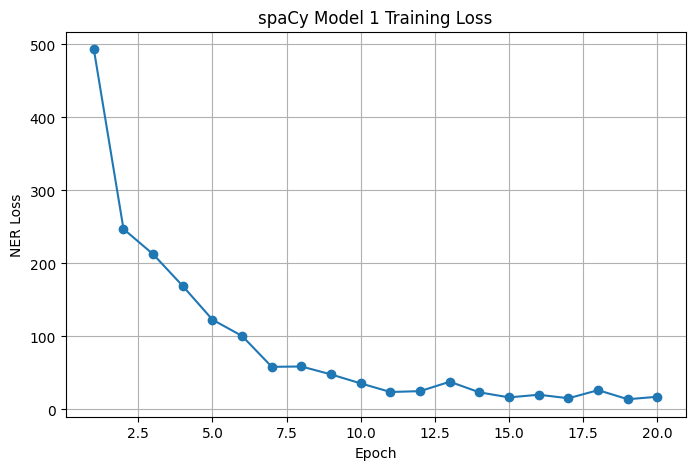


Custom spaCy Model 1 Results
Precision: 0.5238
Recall:    0.3438
F1 Score:  0.4151


In [26]:
import spacy
import random
from sklearn.model_selection import train_test_split
from spacy.training.example import Example
from spacy.scorer import Scorer
import matplotlib.pyplot as plt


# Convert one CoNLL sentence into spaCy format
def conll_sent_to_spacy(sent):
    text = " ".join([token for token, tag in sent])
    entities = []

    start = 0
    current_label = None
    entity_start = None

    for token, tag in sent:
        end = start + len(token)

        if tag.startswith("B-"):
            if current_label is not None:
                entities.append((entity_start, prev_end, current_label))
            current_label = tag[2:]
            entity_start = start

        elif tag.startswith("I-"):
            pass

        else:  # tag == O
            if current_label is not None:
                entities.append((entity_start, prev_end, current_label))
                current_label = None
                entity_start = None

        prev_end = end
        start = end + 1  # account for space

    if current_label is not None:
        entities.append((entity_start, prev_end, current_label))

    return text, {"entities": entities}

# Convert all annotated sentences
spacy_data = [conll_sent_to_spacy(sent) for sent in sentences]

print("Sample example:")
print(spacy_data[0])

# 80/20 split
train_data, test_data = train_test_split(
    spacy_data,
    test_size=0.2,
    random_state=42
)

print(f"Train examples: {len(train_data)}")
print(f"Test examples: {len(test_data)}")

# Create blank English spaCy model
nlp_custom = spacy.blank("en")
ner = nlp_custom.add_pipe("ner")

# Add labels from training data
for _, annotations in train_data:
    for start, end, label in annotations["entities"]:
        ner.add_label(label)

# Initialize model
optimizer = nlp_custom.initialize()

# Train for 20 epochs
n_iter = 20
loss_history = [] # Initialize loss_history list

for epoch in range(n_iter):
    random.shuffle(train_data)
    losses = {}

    for text, annotations in train_data:
        doc = nlp_custom.make_doc(text)
        example = Example.from_dict(doc, annotations)
        nlp_custom.update([example], drop=0.2, losses=losses)

    epoch_loss = losses.get("ner", 0.0) # Get NER loss, default to 0.0 if not present
    loss_history.append(epoch_loss) # Append loss for current epoch
    print(f"Epoch {epoch+1}/{n_iter} - Losses: {losses}")

#Plot Training Loss Curve

plt.figure(figsize=(8,5))
plt.plot(range(1, n_iter + 1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("NER Loss")
plt.title("spaCy Model 1 Training Loss")
plt.grid(True)
plt.show()

# Evaluate on test set
examples = []
for text, annotations in test_data:
    pred_doc = nlp_custom(text)
    example = Example.from_dict(pred_doc, annotations)
    examples.append(example)

scorer = Scorer()
scores = scorer.score(examples)

print("\nCustom spaCy Model 1 Results")
print(f"Precision: {scores['ents_p']:.4f}")
print(f"Recall:    {scores['ents_r']:.4f}")
print(f"F1 Score:  {scores['ents_f']:.4f}")

In [27]:
print("Model 1 Hyperparameters")
print("Framework: spaCy")
print("Base model: blank English pipeline")
print("Train/test split: 80/20")
print("Random state: 42")
print("Epochs: 20")
print("Dropout: 0.2")
print("Labels: PER, ORG, LOC")
print(f"Train examples: {len(train_data)}")
print(f"Test examples: {len(test_data)}")

Model 1 Hyperparameters
Framework: spaCy
Base model: blank English pipeline
Train/test split: 80/20
Random state: 42
Epochs: 20
Dropout: 0.2
Labels: PER, ORG, LOC
Train examples: 166
Test examples: 42


In [28]:
from spacy.scorer import Scorer
from spacy.training.example import Example
import pandas as pd

# Build examples for evaluation
examples = []
for text, annotations in test_data:
    pred_doc = nlp_custom(text)
    example = Example.from_dict(pred_doc, annotations)
    examples.append(example)

# Score the model
scorer = Scorer()
scores = scorer.score(examples)

# Overall metrics
print("Overall Results")
print(f"Precision: {scores['ents_p']:.4f}")
print(f"Recall:    {scores['ents_r']:.4f}")
print(f"F1 Score:  {scores['ents_f']:.4f}")

# Per-entity metrics
print("\nPer-Entity Results")
for label, metrics in scores["ents_per_type"].items():
    print(f"{label}:")
    print(f"  Precision: {metrics['p']:.4f}")
    print(f"  Recall:    {metrics['r']:.4f}")
    print(f"  F1 Score:  {metrics['f']:.4f}")

Overall Results
Precision: 0.5238
Recall:    0.3438
F1 Score:  0.4151

Per-Entity Results
LOC:
  Precision: 0.6667
  Recall:    0.2857
  F1 Score:  0.4000
ORG:
  Precision: 0.5455
  Recall:    0.5455
  F1 Score:  0.5455
PER:
  Precision: 0.4286
  Recall:    0.2143
  F1 Score:  0.2857


In [29]:
per_entity_rows = []

for label, metrics in scores["ents_per_type"].items():
    per_entity_rows.append({
        "Entity": label,
        "Precision": round(metrics["p"], 4),
        "Recall": round(metrics["r"], 4),
        "F1": round(metrics["f"], 4)
    })

per_entity_df = pd.DataFrame(per_entity_rows)
per_entity_df

,Entity,Precision,Recall,F1
0,LOC,0.6667,0.2857,0.4000
1,ORG,0.5455,0.5455,0.5455
2,PER,0.4286,0.2143,0.2857


### Model 1 Per-Entity Performance Analysis

The custom spaCy Model 1 shows a strong precision for correctly labeling location entities (LOC), however the recall remains low suggesting that many location mentions are still missed.

Organization entities (ORG) demonstrate the most balanced performance, with relatively higher recall compared to the other entity types. This suggests the model is better able to identify organization mentions in the Twitter dataset.

Person entities (PER) remain the most difficult category. While precision is moderate, recall is lower, indicating that informal references, abbreviations, and inconsistent capitalization in tweets continue to make person detection challenging.


### Model 1 Overall Performance Summary

Model 1 achieves moderate precision and recall across entity categories, demonstrating successful adaptation to the Twitter domain compared to the pretrained baseline. However the model's ability to recall remains limited due to the relatively small annotated dataset size. Additional annotated examples in Model 2 are expected to improve entity coverage and overall F1 performance.

### Custom Model 2 Training

In [30]:
new_examples = dataset["train"].select(range(200, 300))

LABEL_MAP = {
    "PERSON": "PER",
    "ORG": "ORG",
    "GPE": "LOC",
    "LOC": "LOC",
    "FAC": "LOC"
}

ls_tasks = []

for ex in new_examples:
    text = " ".join(ex["tokens"])
    doc = nlp(text)

    results = []

    for ent in doc.ents:
        if ent.label_ in LABEL_MAP:
            mapped_label = LABEL_MAP[ent.label_]

            results.append({
                "from_name": "label",
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": ent.start_char,
                    "end": ent.end_char,
                    "text": ent.text,
                    "labels": [mapped_label]
                }
            })

    ls_tasks.append({
        "data": {"text": text},
        "predictions": [{"result": results}]
    })

with open("spacy_preannotations_fixed.json", "w", encoding="utf-8") as f:
    json.dump(ls_tasks, f, indent=2, ensure_ascii=False)

In [31]:
import re

def label_studio_to_iob2(ls_data):
    """
    Convert Label Studio JSON export into token-level IOB2 format.
    Keeps only PER, ORG, and LOC labels.
    """

    all_sentences = []

    for task in ls_data:
        text = task.get("data", {}).get("text", "")
        if not text:
            continue

        annotations = task.get("annotations", [])
        if not annotations:
            continue

        results = annotations[0].get("result", [])
        entities = []

        for r in results:
            if r.get("type") == "labels":
                val = r.get("value", {})
                start = val.get("start")
                end = val.get("end")
                labels = val.get("labels", [])

                if start is not None and end is not None and labels:
                    label = labels[0]
                    if label in {"PER", "ORG", "LOC"}:
                        entities.append((start, end, label))

        entities.sort(key=lambda x: x[0])

        # whitespace tokenization with character spans
        tokens = []
        token_spans = []
        for match in re.finditer(r"\S+", text):
            tokens.append(match.group())
            token_spans.append((match.start(), match.end()))

        tags = ["O"] * len(tokens)

        # assign BIO tags where token span overlaps entity span
        for ent_start, ent_end, label in entities:
            started = False
            for i, (tok_start, tok_end) in enumerate(token_spans):
                if tok_end > ent_start and tok_start < ent_end:
                    if not started:
                        tags[i] = f"B-{label}"
                        started = True
                    else:
                        tags[i] = f"I-{label}"

        all_sentences.append(list(zip(tokens, tags)))

    return all_sentences

In [34]:
import requests

In [35]:
url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Assignment4_Fong_Marcela/main/label_studio_export_round2.json"

ls_data_round2 = requests.get(url).json()

new_sentences = label_studio_to_iob2(ls_data_round2)

print("Converted sentences:", len(new_sentences))

Converted sentences: 100


In [36]:
new_spacy_data = [conll_sent_to_spacy(sent) for sent in new_sentences]

combined_data = spacy_data + new_spacy_data
train_data_2 = train_data + new_spacy_data
test_data_2 = test_data
print("Model 1 examples:", len(spacy_data))
print("New round 2 examples:", len(new_spacy_data))
print("Combined examples:", len(combined_data))

Model 1 examples: 208
New round 2 examples: 100
Combined examples: 308


In [37]:
nlp_model2 = spacy.blank("en")
ner2 = nlp_model2.add_pipe("ner")

for _, annotations in train_data_2:
    for start, end, label in annotations["entities"]:
        ner2.add_label(label)

optimizer = nlp_model2.initialize()

n_iter = 20
loss_history_2 = []

for epoch in range(n_iter):
    random.shuffle(train_data_2)
    losses = {}

    for text, annotations in train_data_2:
        doc = nlp_model2.make_doc(text)
        example = Example.from_dict(doc, annotations)
        nlp_model2.update([example], drop=0.2, losses=losses)

    epoch_loss = losses.get("ner", 0)
    loss_history_2.append(epoch_loss)
    print(f"Epoch {epoch+1}/{n_iter} - Loss: {epoch_loss:.4f}")

Epoch 1/20 - Loss: 613.9883
Epoch 2/20 - Loss: 327.7411
Epoch 3/20 - Loss: 272.4959
Epoch 4/20 - Loss: 180.2639
Epoch 5/20 - Loss: 149.2708
Epoch 6/20 - Loss: 114.9715
Epoch 7/20 - Loss: 108.3669
Epoch 8/20 - Loss: 80.2062
Epoch 9/20 - Loss: 82.4139
Epoch 10/20 - Loss: 86.2279
Epoch 11/20 - Loss: 72.2044
Epoch 12/20 - Loss: 70.0922
Epoch 13/20 - Loss: 51.2594
Epoch 14/20 - Loss: 56.7831
Epoch 15/20 - Loss: 56.2016
Epoch 16/20 - Loss: 51.4618
Epoch 17/20 - Loss: 63.9331
Epoch 18/20 - Loss: 53.2831
Epoch 19/20 - Loss: 57.3562
Epoch 20/20 - Loss: 52.2650


In [38]:
examples_2 = []

for text, annotations in test_data_2:
    pred_doc = nlp_model2(text)
    example = Example.from_dict(pred_doc, annotations)
    examples_2.append(example)

scorer = Scorer()
scores_2 = scorer.score(examples_2)

print("\nCustom spaCy Model 2 Results")
print(f"Precision: {scores_2['ents_p']:.4f}")
print(f"Recall:    {scores_2['ents_r']:.4f}")
print(f"F1 Score:  {scores_2['ents_f']:.4f}")


Custom spaCy Model 2 Results
Precision: 0.6538
Recall:    0.5312
F1 Score:  0.5862


In [39]:
per_entity_results_2 = []

for label, vals in scores_2["ents_per_type"].items():
    per_entity_results_2.append({
        "Entity": label,
        "Precision": round(vals["p"], 4),
        "Recall": round(vals["r"], 4),
        "F1 Score": round(vals["f"], 4)
    })

per_entity_df_2 = pd.DataFrame(per_entity_results_2)

per_entity_df_2

,Entity,Precision,Recall,F1 Score
0,LOC,0.7500,0.4286,0.5455
1,ORG,0.7778,0.6364,0.7000
2,PER,0.5385,0.5000,0.5185


In [40]:
comparison = []

for label in scores["ents_per_type"]:
    comparison.append({
        "Entity": label,
        "Model 1 F1": round(scores["ents_per_type"][label]["f"], 4),
        "Model 2 F1": round(scores_2["ents_per_type"][label]["f"], 4)
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Entity,Model 1 F1,Model 2 F1
0,LOC,0.4000,0.5455
1,ORG,0.5455,0.7000
2,PER,0.2857,0.5185
